## Scam Detection using a 1D CNN Model

### Data Loading and Preprocessing

In [1]:
import sys

from data_loader import load_scam_data, load_embeddings

dataset = load_scam_data()
glove = load_embeddings()

glove_weights = glove.vectors

Downloading/Loading SMS Spam dataset...



Sample Data Structure:
{'sms': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n', 'label': 0}

Downloading/Loading GloVe Embeddings...
(Note: This is an ~800MB download the first time you run it. Grab a coffee.)

The shape of the word vector for 'scam' is: torch.Size([100])


In [2]:
## Tokenize and create a vocabulary:

import torch
from collections import Counter

# 1. Flatten all messages to count word frequency
all_text = " ".join(dataset['train']['sms']).lower().split()
word_counts = Counter(all_text)

# 2. Create a vocabulary (only keep words that appear at least twice)
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, count in word_counts.items():
    if count > 1:
        vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")

## Create an embedding matrix using GloVe vectors:

embedding_dim = 100
# Initialize matrix with zeros or random numbers
target_vocab_size = len(vocab)
embedding_matrix = torch.zeros((target_vocab_size, embedding_dim))

for word, idx in vocab.items():
    if word in glove.stoi: # Check if word exists in GloVe
        embedding_matrix[idx] = glove.vectors[glove.stoi[word]]
    else:
        # For <UNK> or missing words, use a random normal vector
        embedding_matrix[idx] = torch.randn(embedding_dim)

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Vocabulary size: 5545
Embedding matrix shape: torch.Size([5545, 100])


In [3]:
## Numberize and pad the messages:

def encode_and_pad(text, max_len=50):
    tokens = text.lower().split()
    # Convert words to indices
    indices = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    # Pad or Truncate
    if len(indices) < max_len:
        indices += [vocab["<PAD>"]] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

# Apply to the dataset
train_data = [encode_and_pad(msg) for msg in dataset['train']['sms']]
train_labels = dataset['train']['label'] # 0 for ham, 1 for spam

# Convert to Tensors
X_train = torch.tensor(train_data)
y_train = torch.tensor(train_labels)

In [6]:
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import WeightedRandomSampler


# 1. Split the original Hugging Face dataset (if you haven't already)
# This creates a 80/20 split
split_dataset = dataset['train'].train_test_split(test_size=0.2, seed=42)

# 2. Process Training Data (Re-doing this to ensure consistency)
train_msgs = [encode_and_pad(msg) for msg in split_dataset['train']['sms']]
train_labels = split_dataset['train']['label']
X_train = torch.tensor(train_msgs)
y_train = torch.tensor(train_labels)

# 3. Process Test Data (The missing piece!)
test_msgs = [encode_and_pad(msg) for msg in split_dataset['test']['sms']]
test_labels = split_dataset['test']['label']
X_test = torch.tensor(test_msgs)
y_test = torch.tensor(test_labels)

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

Train samples: 4459, Test samples: 1115


### Data Visualization

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# basic look
df = pd.DataFrame(dataset['train'])
print(df.head())
print(df['label'].value_counts())  # 0=ham (safe), 1=spam (scam)

# class distribution (same as LSTM)
sns.countplot(x=pd.Series(dataset['train']['label']))
plt.xticks([0,1], ["Safe", "Scam"])
plt.title("Dataset Class Distribution")
plt.show()

# message length distribution
df['length'] = df['sms'].apply(lambda x: len(x.split()))
df.groupby('label')['length'].hist(alpha=0.6, bins=30)
plt.xlabel("Message length (words)")
plt.legend(["Safe", "Scam"])
plt.show()

### Note on Class Imbalance Handling

The SMS Spam dataset is imbalanced — roughly 87% ham and 13% spam. Without correction, models are biased toward predicting "ham" since that minimizes overall loss, leading to poor spam recall.

To investigate the impact of different balancing strategies, we train and compare four configurations:

**Baseline** — no balancing applied. The model trains on the raw imbalanced distribution. Included as a reference point to quantify how much imbalance actually hurts performance.

**WeightedRandomSampler** — oversamples spam messages at the data loading level, so each training batch sees roughly equal ham and spam. Combined with `pos_weight` in the loss function, which additionally penalises missed spam predictions during backpropagation. No new data is created — existing spam messages are simply shown more often.

**SMOTE (Synthetic Minority Oversampling Technique)** — generates synthetic spam samples by interpolating between real spam messages in GloVe embedding space. Unlike the sampler, SMOTE physically augments the training set, giving the model exposure to a denser coverage of the spam region in embedding space. Applied only to training data — the test set remains untouched to reflect real-world distribution.

**ADASYN (Adaptive Synthetic Sampling)** — similar to SMOTE but adaptive: it generates more synthetic samples in regions where spam messages are hardest to classify (i.e. closest to ham in embedding space). This focuses the model's attention on borderline cases rather than spreading synthetic samples uniformly across the spam region.

All four configurations are evaluated on the same held-out test set using precision, recall, F1, and accuracy at threshold=0.35.

### CNN Model

In [7]:
import torch
import torch.nn as nn

class TextCNN(nn.Module):
    def __init__(self, embedding_matrix, num_filters=128, kernel_sizes=[3,4,5], dropout=0.5):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(embedding_matrix.clone())
        self.embedding.weight.requires_grad = True
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x, already_embedded=False):
        if not already_embedded:
            x = self.embedding(x)       # [batch, 50, 100]
        x = x.permute(0, 2, 1)         # [batch, 100, 50]
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(x))
            c = c.max(dim=2).values
            pooled.append(c)
        x = torch.cat(pooled, dim=1)
        x = self.dropout(x)
        return self.fc(x).squeeze(1)

def build_model():
    """Always calling a fresh model to not reuse weights across configs."""
    return TextCNN(embedding_matrix).to(device)

In [8]:
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from imblearn.over_sampling import SMOTE, ADASYN

batch_size = 32
test_dataset  = TensorDataset(X_test, y_test)
test_loader   = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --- Baseline ---
train_dataset = TensorDataset(X_train, y_train)
baseline_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# --- WeightedSampler ---
class_counts   = torch.bincount(y_train)
class_weights  = 1.0 / class_counts.float()
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
sampler_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)

# --- SMOTE ---
# Get embeddings for training data (no grad needed, just lookup)
temp_model = TextCNN(embedding_matrix)
with torch.no_grad():
    X_train_embedded = temp_model.embedding(X_train)  # [4459, 50, 100]

X_flat    = X_train_embedded.numpy().reshape(len(X_train), -1)  # [4459, 5000]
y_flat    = y_train.numpy()

print(f"Before SMOTE: {y_flat.sum()} spam, {(y_flat==0).sum()} ham")
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_flat, y_flat)
print(f"After SMOTE:  {y_smote.sum()} spam, {(y_smote==0).sum()} ham")

X_smote_tensor = torch.tensor(X_smote.reshape(-1, 50, 100), dtype=torch.float32)
y_smote_tensor = torch.tensor(y_smote, dtype=torch.float32)
smote_dataset  = TensorDataset(X_smote_tensor, y_smote_tensor)
smote_loader   = DataLoader(smote_dataset, batch_size=batch_size, shuffle=True)

# --- ADASYN ---
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_flat, y_flat)  # reuses X_flat, y_flat from SMOTE block
print(f"After ADASYN: {y_adasyn.sum()} spam, {(y_adasyn==0).sum()} ham")

X_adasyn_tensor = torch.tensor(X_adasyn.reshape(-1, 50, 100), dtype=torch.float32)
y_adasyn_tensor = torch.tensor(y_adasyn, dtype=torch.float32)
adasyn_dataset  = TensorDataset(X_adasyn_tensor, y_adasyn_tensor)
adasyn_loader   = DataLoader(adasyn_dataset, batch_size=batch_size, shuffle=True)

print("All loaders ready.")

# Testing a batch
sample_x, sample_y = next(iter(baseline_loader))
print(f"Batch X shape for baseline: {sample_x.shape}") # Should be [32, 50]

sample_a, sample_b = next(iter(sampler_loader))
print(f"Batch X shape for weighted sampler: {sample_a.shape}") # Should be [32, 50]

sample_c, sample_d = next(iter(adasyn_loader))
print(f"Batch X shape for SMOTE: {sample_c.shape}") # Should be [32, 50, 100]

sample_e, sample_f = next(iter(smote_loader))
print(f"Batch X shape for ADASYN: {sample_e.shape}") # Should be [32, 50, 100]


Before SMOTE: 598 spam, 3861 ham
After SMOTE:  3861 spam, 3861 ham
After ADASYN: 3801 spam, 3861 ham
All loaders ready.
Batch X shape for baseline: torch.Size([32, 50])
Batch X shape for weighted sampler: torch.Size([32, 50])
Batch X shape for SMOTE: torch.Size([32, 50, 100])
Batch X shape for ADASYN: torch.Size([32, 50, 100])


### Training and Evaluation Loop

In [9]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Custom Focal Loss implementation: smarter loss fxn than BCE for imbalanced data
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha  # weight for positive class (spam)
        self.gamma = gamma  # focusing parameter —> higher = more focus on hard examples

    def forward(self, logits, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        probs  = torch.sigmoid(logits)
        pt     = torch.where(targets == 1, probs, 1 - probs)
        alpha_t = torch.where(targets == 1,
                              torch.full_like(targets, self.alpha),
                              torch.full_like(targets, 1 - self.alpha))
        loss = alpha_t * ((1 - pt) ** self.gamma) * bce_loss
        return loss.mean()

device = torch.device('cpu')

def train_epoch(model, loader, optimizer, criterion, already_embedded=False):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.float().to(device)
        optimizer.zero_grad()
        preds = model(X_batch, already_embedded=already_embedded)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def get_probs(model, loader, already_embedded=False):
    # collecting predicted probabilities and true labels on test set
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch, already_embedded=already_embedded)
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.numpy())
    return np.array(all_probs), np.array(all_labels)

def compute_metrics(all_probs, all_labels, threshold=0.45):
    preds = (all_probs >= threshold).astype(int)
    return {
        "accuracy":  accuracy_score(all_labels, preds),
        "precision": precision_score(all_labels, preds, zero_division=0),
        "recall":    recall_score(all_labels, preds, zero_division=0),
        "f1":        f1_score(all_labels, preds, zero_division=0),
    }

Notes for self:
- Early stopping for epochs has been implemented
- Tweaking the weightedsampler parameters

Different configurations being tested:
- Baseline → same data, standard loss
- WeightedSampler → different data distribution, weighted loss
- SMOTE → augmented data, standard loss  
- ADASYN → augmented data, standard loss
- FocalLoss → same data, smarter loss
- FocalLoss+WeightedSampler → same data, smarter loss       

In [10]:
import pandas as pd

EPOCHS = 20

configs = [
    {
        "name":             "Baseline",
        "loader":           baseline_loader,
        "already_embedded": False,
        "pos_weight":       None,
    },
    {
        "name":             "WeightedSampler",
        "loader":           sampler_loader,
        "already_embedded": False,
        "pos_weight":       6.5,
    },
    {
        "name":             "SMOTE",
        "loader":           smote_loader,
        "already_embedded": True,
        "pos_weight":       None,
    },
    {                                    
        "name":             "ADASYN",
        "loader":           adasyn_loader,
        "already_embedded": True,
        "pos_weight":       None,
    },
    {
    "name":             "FocalLoss",
    "loader":           baseline_loader,
    "already_embedded": False,
    "pos_weight":       None,
    "criterion":        FocalLoss(alpha=0.25, gamma=2.0),
    },
    {
    "name":             "FocalLoss+WeightedSampler",
    "loader":           sampler_loader,       # resampled loader
    "already_embedded": False,
    "pos_weight":       None,
    "criterion":        FocalLoss(alpha=0.25, gamma=2.0),  # smarter loss
    },
]

results = []
trained_models = {} # can remove added for debugging later

for cfg in configs:
    print(f"\n{'='*50}")
    print(f"Training: {cfg['name']}")
    print('='*50)

    model     = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    if "criterion" in cfg:
        # config brought its own loss function (FocalLoss, FocalLoss+WeightedSampler)
        criterion = cfg["criterion"]
    elif cfg["pos_weight"]:
        # config wants weighted BCE (WeightedSampler)
        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([cfg["pos_weight"]]).to(device)
        )
    else:
        # plain BCE, no special handling (Baseline, SMOTE, ADASYN)
        criterion = nn.BCEWithLogitsLoss()
    
    # Early stopping setup
    best_f1   = 0.0
    best_model_wts = None
    patience      = 5
    no_improve    = 0

    for epoch in range(EPOCHS):
        loss = train_epoch(model, cfg["loader"], optimizer, criterion,
                           already_embedded=cfg["already_embedded"])
        # evaluate on test set each epoch for early stopping
        probs_tmp, labels_tmp = get_probs(model, test_loader, already_embedded=False)
        metrics_tmp = compute_metrics(probs_tmp, labels_tmp)
        print(f"  Epoch {epoch+1}/{EPOCHS} | loss={loss:.4f} | recall={metrics_tmp['recall']:.4f} | f1={metrics_tmp['f1']:.4f}")

        # Track best f1
        if metrics_tmp["f1"] > best_f1:
            best_f1    = metrics_tmp["f1"]
            best_model_wts = model.state_dict().copy()  # save best weights
            no_improve     = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"  Early stopping at epoch {epoch+1} — no F1 improvement for {patience} epochs")
            break
    
    # Restore best weights before evaluating
    model.load_state_dict(best_model_wts)

    # test_loader always uses token IDs, not embeddings
    all_probs, all_labels = get_probs(model, test_loader, already_embedded=False)
    metrics = compute_metrics(all_probs, all_labels, threshold=0.45)
    metrics["name"] = cfg["name"]
    results.append(metrics)
    trained_models[cfg["name"]] = (model, all_probs, all_labels)

    print(f"\n  Results for {cfg['name']}:")
    print(f"  Accuracy={metrics['accuracy']:.4f} | Precision={metrics['precision']:.4f} | Recall={metrics['recall']:.4f} | F1={metrics['f1']:.4f}")

# Final comparison tables
print("\n\n===== FINAL COMPARISON =====")
df = pd.DataFrame(results)[["name", "accuracy", "precision", "recall", "f1"]]
df.columns = ["Config", "Accuracy", "Precision", "Recall", "F1"]
print(df.to_string(index=False))


Training: Baseline
  Epoch 1/20 | loss=0.2005 | recall=0.8859 | f1=0.9167
  Epoch 2/20 | loss=0.0735 | recall=0.8993 | f1=0.9178
  Epoch 3/20 | loss=0.0405 | recall=0.8993 | f1=0.9273
  Epoch 4/20 | loss=0.0266 | recall=0.8859 | f1=0.9199
  Epoch 5/20 | loss=0.0167 | recall=0.8792 | f1=0.9225
  Epoch 6/20 | loss=0.0096 | recall=0.8993 | f1=0.9273
  Epoch 7/20 | loss=0.0077 | recall=0.9060 | f1=0.9310
  Epoch 8/20 | loss=0.0051 | recall=0.8859 | f1=0.9231
  Epoch 9/20 | loss=0.0041 | recall=0.8993 | f1=0.9306
  Epoch 10/20 | loss=0.0043 | recall=0.8993 | f1=0.9306
  Epoch 11/20 | loss=0.0038 | recall=0.8926 | f1=0.9301
  Epoch 12/20 | loss=0.0030 | recall=0.8859 | f1=0.9263
  Early stopping at epoch 12 — no F1 improvement for 5 epochs

  Results for Baseline:
  Accuracy=0.9812 | Precision=0.9706 | Recall=0.8859 | F1=0.9263

Training: WeightedSampler
  Epoch 1/20 | loss=0.8530 | recall=0.9799 | f1=0.5489
  Epoch 2/20 | loss=0.2019 | recall=0.9463 | f1=0.8034
  Epoch 3/20 | loss=0.1004 |

### Threshold Analysis & Confusion Matrices

Sweeping decision thresholds from 0.30 to 0.70 to identify the optimal operating point for each configuration. Since recall is our primary concern (missing a scam is worse than a false alarm), we select the threshold that maximises F1 as a balanced proxy. Confusion matrices are shown at each config's best threshold.

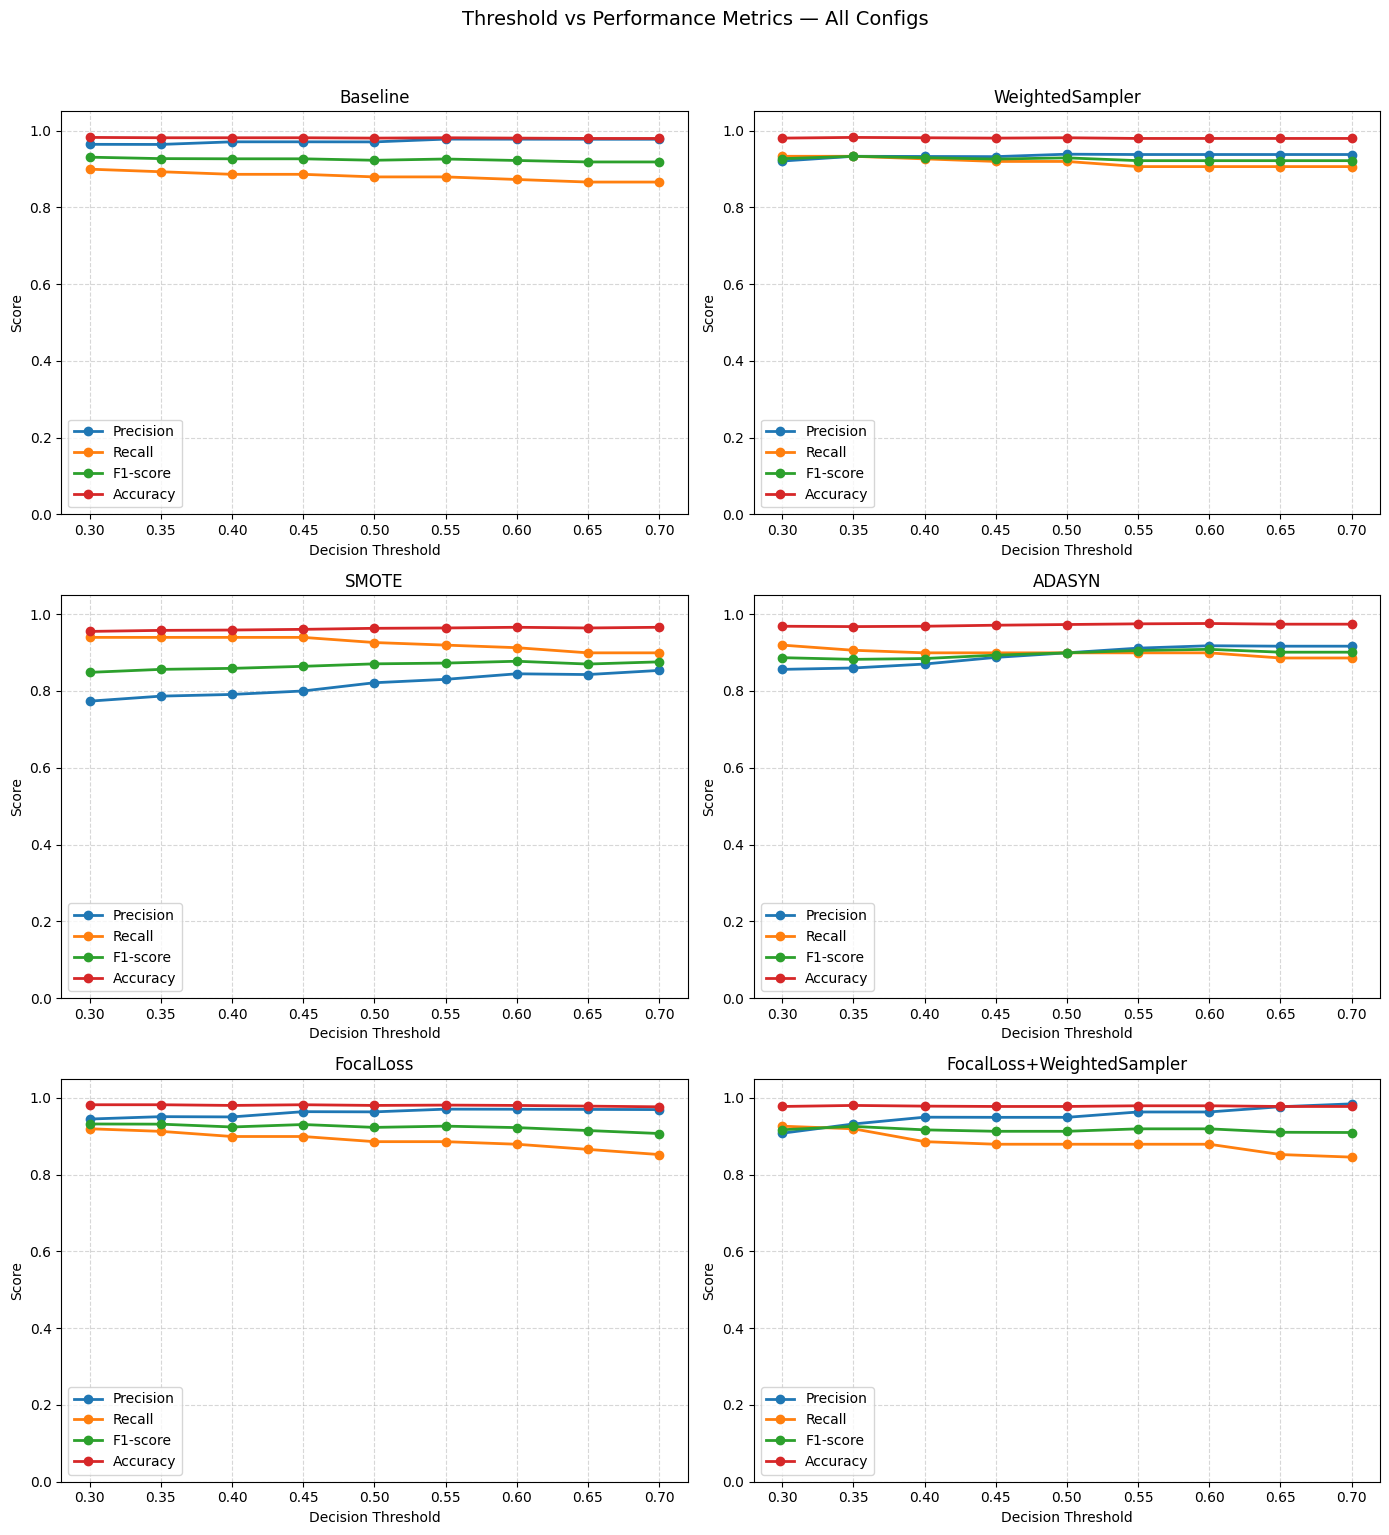

===== BEST THRESHOLD PER CONFIG =====

Baseline: best threshold=0.3 | recall=0.8993 | f1=0.9306
WeightedSampler: best threshold=0.35 | recall=0.9329 | f1=0.9329
SMOTE: best threshold=0.6 | recall=0.9128 | f1=0.8774
ADASYN: best threshold=0.6 | recall=0.8993 | f1=0.9085
FocalLoss: best threshold=0.3 | recall=0.9195 | f1=0.9320
FocalLoss+WeightedSampler: best threshold=0.35 | recall=0.9195 | f1=0.9257

===== FINAL COMPARISON AT BEST THRESHOLDS =====
                   Config  Threshold  Accuracy  Precision   Recall       F1
                 Baseline       0.30  0.982063   0.964029 0.899329 0.930556
          WeightedSampler       0.35  0.982063   0.932886 0.932886 0.932886
                    SMOTE       0.60  0.965919   0.844720 0.912752 0.877419
                   ADASYN       0.60  0.975785   0.917808 0.899329 0.908475
                FocalLoss       0.30  0.982063   0.944828 0.919463 0.931973
FocalLoss+WeightedSampler       0.35  0.980269   0.931973 0.919463 0.925676


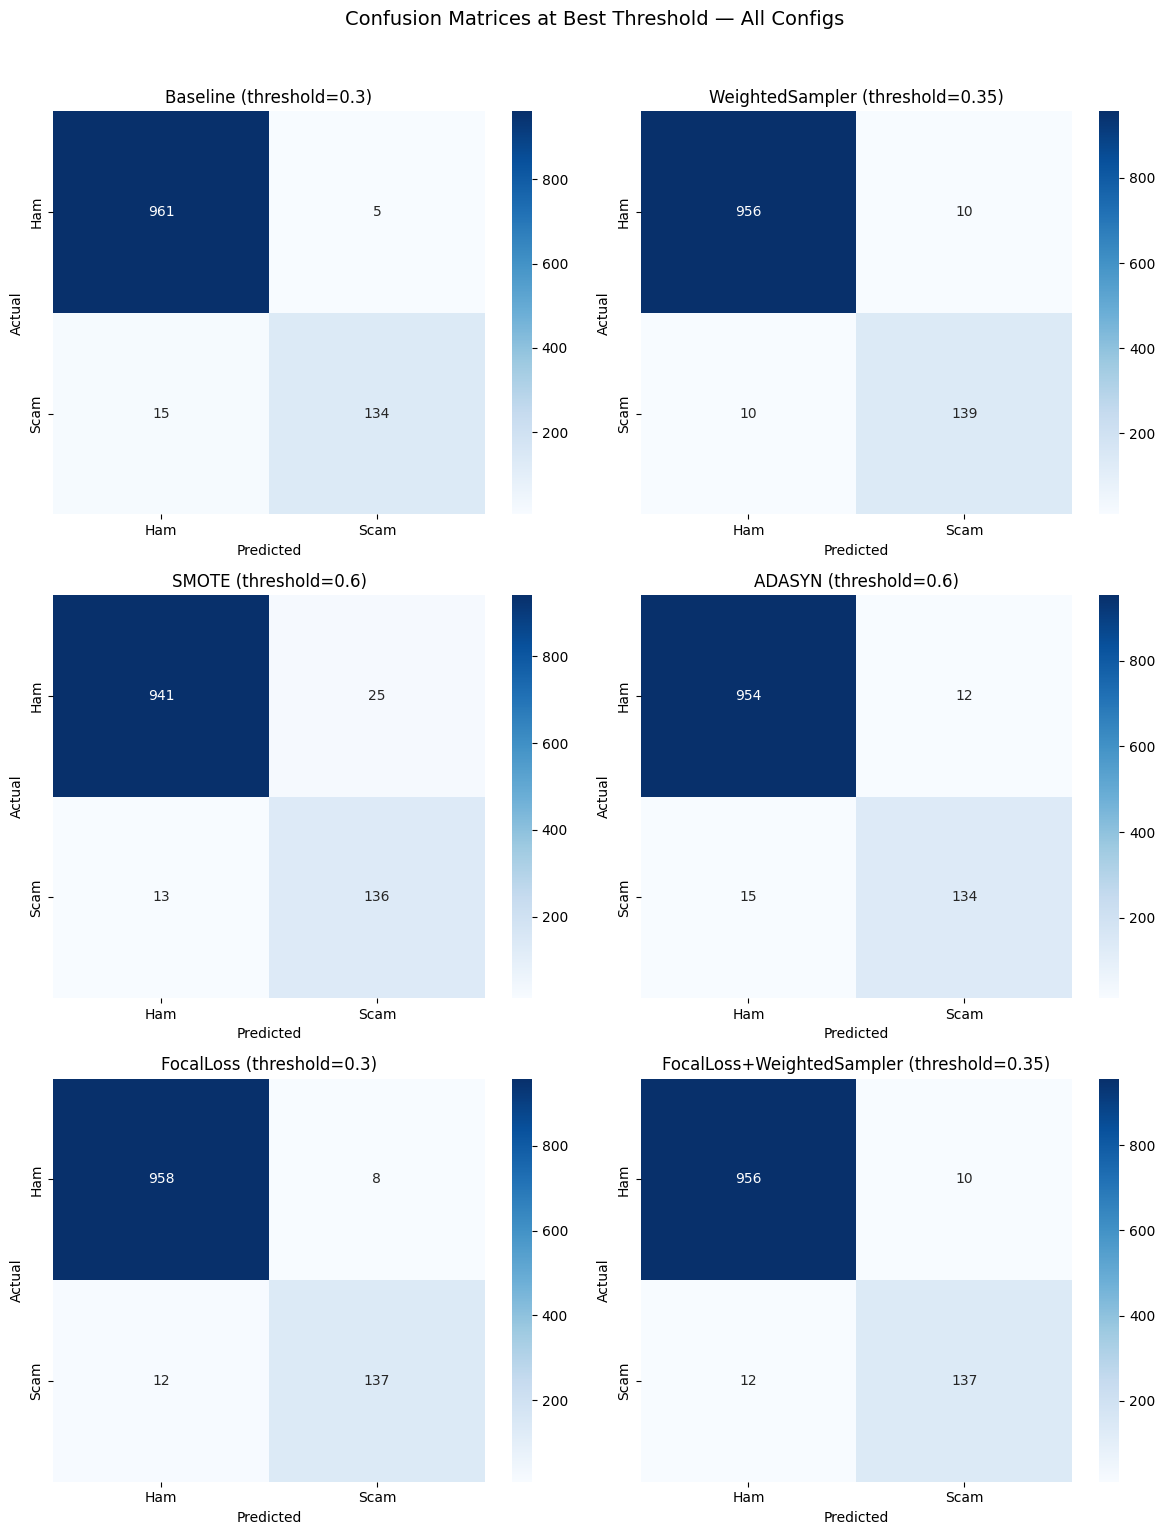

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_configs = len(trained_models)
n_cols    = 2
n_rows    = math.ceil(n_configs / n_cols)

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

# --- Threshold sweep plots ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, (cfg_name, (model, all_probs, all_labels)) in enumerate(trained_models.items()):
    precisions, recalls, f1s, accuracies = [], [], [], []

    for t in thresholds:
        preds_t = (all_probs >= t).astype(int)
        accuracies.append(accuracy_score(all_labels, preds_t))
        precisions.append(precision_score(all_labels, preds_t, zero_division=0))
        recalls.append(recall_score(all_labels, preds_t, zero_division=0))
        f1s.append(f1_score(all_labels, preds_t, zero_division=0))

    ax = axes[i]
    ax.plot(thresholds, precisions, marker='o', linewidth=2, label='Precision')
    ax.plot(thresholds, recalls,    marker='o', linewidth=2, label='Recall')
    ax.plot(thresholds, f1s,        marker='o', linewidth=2, label='F1-score')
    ax.plot(thresholds, accuracies, marker='o', linewidth=2, label='Accuracy')
    ax.set_title(f'{cfg_name}')
    ax.set_xlabel('Decision Threshold')
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.05])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.suptitle('Threshold vs Performance Metrics — All Configs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Best threshold per config ---
print("===== BEST THRESHOLD PER CONFIG =====\n")

best_threshold_results = []
best_preds_per_cfg = {}  # store best preds for confusion matrices

for cfg_name, (model, all_probs, all_labels) in trained_models.items():
    best_t    = 0.5
    best_f1   = 0.0
    best_metrics = {}
    best_preds = None

    for t in thresholds:
        preds_t = (all_probs >= t).astype(int)
        f1_t = f1_score(all_labels, preds_t, zero_division=0)
        if f1_t > best_f1:
            best_f1    = f1_t
            best_t     = t
            best_preds = preds_t
            best_metrics = {
                "name":      cfg_name,
                "threshold": best_t,
                "accuracy":  accuracy_score(all_labels, preds_t),
                "precision": precision_score(all_labels, preds_t, zero_division=0),
                "recall":    recall_score(all_labels, preds_t, zero_division=0),
                "f1":        f1_t,
            }

    best_threshold_results.append(best_metrics)
    best_preds_per_cfg[cfg_name] = (best_preds, all_labels, best_t)
    print(f"{cfg_name}: best threshold={best_t} | recall={best_metrics['recall']:.4f} | f1={best_metrics['f1']:.4f}")

print("\n===== FINAL COMPARISON AT BEST THRESHOLDS =====")
df_best = pd.DataFrame(best_threshold_results)[["name", "threshold", "accuracy", "precision", "recall", "f1"]]
df_best.columns = ["Config", "Threshold", "Accuracy", "Precision", "Recall", "F1"]
print(df_best.to_string(index=False))

# --- Confusion matrices at best threshold ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for i, (cfg_name, (best_preds, all_labels, best_t)) in enumerate(best_preds_per_cfg.items()):
    cm = confusion_matrix(all_labels, best_preds)
    ax = axes[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Scam'],
                yticklabels=['Ham', 'Scam'])
    ax.set_title(f'{cfg_name} (threshold={best_t})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices at Best Threshold — All Configs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import roc_auc_score

# --- ROC-AUC for all configs ---
print("ROC-AUC SCORES")
for cfg_name, (model, all_probs, all_labels) in trained_models.items():
    auc = roc_auc_score(all_labels, all_probs)
    print(f"{cfg_name}: AUC={auc:.4f}")

# --- Full classification report for best model (FocalLoss at threshold=0.30) ---
print("\nCLASSIFICATION REPORT — FocalLoss (threshold=0.30)")
best_model, best_probs, best_labels = trained_models["FocalLoss"]
best_preds = (best_probs >= 0.30).astype(int)
print(classification_report(best_labels, best_preds, target_names=["Ham", "Scam"]))

# --- Save best model weights ---
torch.save(trained_models["FocalLoss"][0].state_dict(), "best_cnn_focalloss.pt")
print("Best model saved to best_cnn_focalloss.pt")

ROC-AUC SCORES
Baseline: AUC=0.9842
WeightedSampler: AUC=0.9875
SMOTE: AUC=0.9818
ADASYN: AUC=0.9836
FocalLoss: AUC=0.9855
FocalLoss+WeightedSampler: AUC=0.9860

CLASSIFICATION REPORT — FocalLoss (threshold=0.30)
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Scam       0.94      0.92      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Best model saved to best_cnn_focalloss.pt
